# One-parameter HMC vs SBI using a single $C_\ell$ probe

This notebook compares NumPyro NUTS and SNPE on exactly the same
fixed-covariance analytical likelihood.  Its defaults are:

- datavector: `gy` only;
- sampled parameter: `theta_ej_0` only;
- fixed parameter: `nu_theta_ej_M = -0.1`, matching the saved
  fiducial product;
- fast fiducial-linearized theory response with score compression for
  SBI.

The two user-facing switches are the first two assignments in the
configuration cell below.  Set `DATAVECTOR = "gtau"` for the `gtau`
datavector, or `PARAMETER_MODE = "2d"` to sample both `theta_ej_0` and
`nu_theta_ej_M`.  Probe/mode-specific output directories prevent a
stale result from another configuration from being loaded.

In 1D, the notebook also overlays the exact truncated-Gaussian
posterior implied by this linearized likelihood.  That curve is an
independent reference for both HMC and SBI.

In [1]:
import json
import os
import pathlib
import sys

# Keep this comparison reproducible and avoid JAX/Torch GPU contention.
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

%matplotlib inline

CANDIDATES = [
    pathlib.Path.cwd(),
    pathlib.Path.cwd() / "notebooks" / "SBI_validate",
    pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate"),
]
THIS_DIR = next(p for p in CANDIDATES if (p / "theory_sbi_utils.py").exists())
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from theory_sbi_utils import (
    DEFAULT_FIDUCIAL_PATH,
    THEORY_SBI_DIR,
    default_parameter_specs,
    ensure_default_fiducial_product,
    parse_probe_list,
    selected_product_arrays,
)
from run_hmc_theory_cls import run_hmc
from run_sbi_theory_cls import run_sbi

plt.rcParams.update({"figure.dpi": 130, "axes.grid": False})

In [2]:
# ------------------------------------------------------------------
# USER SWITCHES: these are the only two lines needed for gy/gtau and
# 1D/2D comparisons.
# DATAVECTOR = "gy"          # change to "gtau"
DATAVECTOR = "gtau"          # change to "gy"
PARAMETER_MODE = "1d"      # change to "2d"
# ------------------------------------------------------------------

THEORY_BACKEND = "linearized"
FIDUCIAL_OFFSET = True
ELL_MIN = None
ELL_MAX = None

# Missing outputs are generated when these are True. Existing outputs
# are reused unless FORCE_RERUN is True.
RUN_HMC = True
RUN_SBI = True
FORCE_RERUN = False

assert DATAVECTOR in {"gy", "gtau"}
assert PARAMETER_MODE in {"1d", "2d"}

FULL_PARAM_SPECS = default_parameter_specs()
active_names = (
    ("theta_ej_0",)
    if PARAMETER_MODE == "1d"
    else ("theta_ej_0", "nu_theta_ej_M")
)
PARAM_SPECS = [p for p in FULL_PARAM_SPECS if p.name in active_names]
FIXED_PARAM_SPECS = [p for p in FULL_PARAM_SPECS if p.name not in active_names]
PROBES = parse_probe_list(DATAVECTOR)

# Always create/validate the product with the full fiducial definition.
# In 1D the omitted nu parameter is then explicitly fixed at -0.1 in
# every theory evaluation rather than falling back to the YAML default.
FIDUCIAL_PATH = ensure_default_fiducial_product(
    DEFAULT_FIDUCIAL_PATH,
    param_specs=FULL_PARAM_SPECS,
    force=False,
)

# One Gaussian component is the natural estimator for the default 1D
# linear-Gaussian target. Keep extra mixture flexibility in 2D.
SBI_NUM_COMPONENTS = 1 if PARAMETER_MODE == "1d" else 5
estimator_tag = f"score_fisher_mdn{SBI_NUM_COMPONENTS}"
run_tag = f"{DATAVECTOR}_{PARAMETER_MODE}_{THEORY_BACKEND}_{estimator_tag}"
RUN_ROOT = THEORY_SBI_DIR / f"compare_hmc_sbi_{run_tag}"
HMC_RUN_DIR = RUN_ROOT / "hmc"
SBI_RUN_DIR = RUN_ROOT / "sbi"

HMC_SETTINGS = {
    "num_warmup": 1500 if PARAMETER_MODE == "1d" else 3000,
    "num_samples": 3000 if PARAMETER_MODE == "1d" else 4000,
    "num_chains": 4,
    "max_tree_depth": 8,
    "target_accept_prob": 0.9,
    "seed": 42,
}
SBI_SETTINGS = {
    # The nearly degenerate gy-only 2D posterior needs a larger training budget.
    "simulations_per_round": (
        [1024, 1024, 2048]
        if PARAMETER_MODE == "1d"
        else [4096, 4096, 8192]
    ),
    "posterior_samples": 30000,
    "seed": 123,
    "hidden_features": 64,
    "num_components": SBI_NUM_COMPONENTS,
    "training_batch_size": 256,
    "max_num_epochs": 200,
}

configuration = pd.DataFrame(
    [
        {"setting": "datavector", "value": DATAVECTOR},
        {"setting": "sampled", "value": ", ".join(p.name for p in PARAM_SPECS)},
        {
            "setting": "fixed",
            "value": ", ".join(f"{p.name}={p.fiducial}" for p in FIXED_PARAM_SPECS) or "none",
        },
        {"setting": "theory backend", "value": THEORY_BACKEND},
        {"setting": "SBI estimator", "value": f"MDN{SBI_NUM_COMPONENTS}"},
        {"setting": "run root", "value": str(RUN_ROOT)},
    ]
)
display(configuration)

,setting,value
0,datavector,gtau
1,sampled,theta_ej_0
2,fixed,nu_theta_ej_M=-0.1
3,theory backend,linearized
4,SBI estimator,MDN1
5,run root,/mnt/ceph/users/spandey/ltu-godmax/GODMAX/note...


selected probes: ('gtau',)
datavector shape: (20,)
covariance shape: (20, 20)
covariance jitter: 0.0
fiducial overrides: {'nu_theta_ej_M': -0.1, 'theta_ej_0': 2.0}


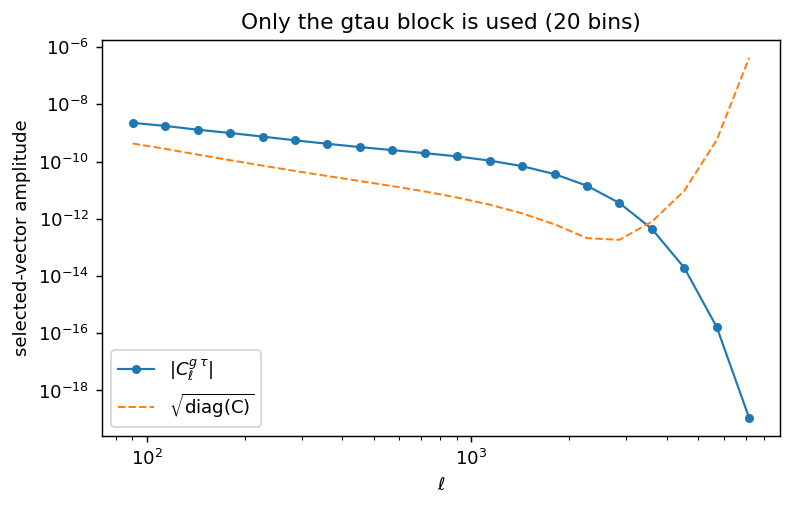

In [3]:
selected = selected_product_arrays(
    FIDUCIAL_PATH,
    probes=PROBES,
    ell_min=ELL_MIN,
    ell_max=ELL_MAX,
)
product = selected["product"]
selection = selected["selection"]
product_meta = product["metadata"]

assert selection.probes == PROBES == (DATAVECTOR,)
fiducial_overrides = product_meta.get("sim_param_overrides", {})
for spec in FULL_PARAM_SPECS:
    actual = fiducial_overrides.get(spec.name)
    assert actual is not None and np.isclose(actual, spec.fiducial), (
        f"Saved product has {spec.name}={actual}; expected {spec.fiducial}. "
        "Regenerate the fiducial product before inference."
    )

print("selected probes:", selection.probes)
print("datavector shape:", selected["data_vector"].shape)
print("covariance shape:", selected["cov"].shape)
print("covariance jitter:", selected["jitter"])
print("fiducial overrides:", fiducial_overrides)

ell = np.asarray(product["ell"])[selection.ell_indices]
data = np.asarray(selected["data_vector"])
sigma_data = np.sqrt(np.diag(selected["cov"]))

probe_tex = {"gy": "y", "gtau": r"\tau"}[DATAVECTOR]
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.loglog(ell, np.abs(data), "o-", ms=4, lw=1.2, label=fr"$|C_\ell^{{g\,{probe_tex}}}|$")
ax.loglog(ell, sigma_data, "--", lw=1.1, label=r"$\sqrt{\mathrm{diag}(\mathsf{C})}$")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"selected-vector amplitude")
ax.set_title(f"Only the {DATAVECTOR} block is used ({len(data)} bins)")
ax.legend()
fig.tight_layout()

## Generate or reuse matched inference results

Both methods below use the same selected data, covariance, prior,
theory backend, and explicitly fixed parameters.  The run functions
save their configuration in each result file.  With the default flags,
missing results are generated once and subsequently reused.  Set
`FORCE_RERUN = True` to deliberately replace a matching run.

In [4]:
hmc_path = HMC_RUN_DIR / "hmc_samples.npz"
sbi_path = SBI_RUN_DIR / "sbi_posterior_samples.npz"

if RUN_HMC and (FORCE_RERUN or not hmc_path.exists()):
    print("Running NUTS:", HMC_RUN_DIR)
    run_hmc(
        fiducial_path=FIDUCIAL_PATH,
        output_dir=HMC_RUN_DIR,
        probes=PROBES,
        param_specs=PARAM_SPECS,
        fixed_param_specs=FIXED_PARAM_SPECS,
        ell_min=ELL_MIN,
        ell_max=ELL_MAX,
        num_warmup=HMC_SETTINGS["num_warmup"],
        num_samples=HMC_SETTINGS["num_samples"],
        num_chains=HMC_SETTINGS["num_chains"],
        max_tree_depth=HMC_SETTINGS["max_tree_depth"],
        dense_mass=len(PARAM_SPECS) > 1,
        target_accept_prob=HMC_SETTINGS["target_accept_prob"],
        seed=HMC_SETTINGS["seed"],
        chain_method="vectorized",
        jit_compile=True,
        fiducial_offset=FIDUCIAL_OFFSET,
        theory_backend=THEORY_BACKEND,
    )
else:
    print("Reusing NUTS output:" if hmc_path.exists() else "NUTS output not requested:", hmc_path)

if RUN_SBI and (FORCE_RERUN or not sbi_path.exists()):
    print("Running SNPE:", SBI_RUN_DIR)
    run_sbi(
        fiducial_path=FIDUCIAL_PATH,
        output_dir=SBI_RUN_DIR,
        probes=PROBES,
        param_specs=PARAM_SPECS,
        fixed_param_specs=FIXED_PARAM_SPECS,
        ell_min=ELL_MIN,
        ell_max=ELL_MAX,
        simulations_per_round=SBI_SETTINGS["simulations_per_round"],
        posterior_samples=SBI_SETTINGS["posterior_samples"],
        seed=SBI_SETTINGS["seed"],
        hidden_features=SBI_SETTINGS["hidden_features"],
        num_transforms=5,
        density_estimator_model="mdn",
        num_components=SBI_SETTINGS["num_components"],
        num_bins=10,
        training_batch_size=SBI_SETTINGS["training_batch_size"],
        max_num_epochs=SBI_SETTINGS["max_num_epochs"],
        jit_compile=True,
        fiducial_offset=FIDUCIAL_OFFSET,
        theory_backend=THEORY_BACKEND,
        summary_compression="score",
        device="cpu",
        discard_prior_samples=True,
        retrain_from_scratch=True,
        force_first_round_loss=False,
        num_atoms=20,
        validation_fraction=0.1,
        learning_rate=5.0e-4,
        parameter_transform="fisher",
    )
else:
    print("Reusing SNPE output:" if sbi_path.exists() else "SNPE output not requested:", sbi_path)

Running NUTS: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/compare_hmc_sbi_gtau_1d_linearized_score_fisher_mdn1/hmc


[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


sample: 100%|██████████| 4500/4500 [00:02<00:00, 1935.17it/s]


Running SNPE: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/compare_hmc_sbi_gtau_1d_linearized_score_fisher_mdn1/sbi
[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)
 Training neural network. Epochs trained: 201
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 201
        Best validation performance: -1.8243
        -------------------------
        


Drawing 2048 posterior samples:   0%|          | 0/2048 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 96 epochs.
        -------------------------
        ||||| ROUND 2 STATS |||||:
        -------------------------
        Epochs trained: 96
        Best validation performance: -2.0274
        -------------------------
        


Drawing 4096 posterior samples:   0%|          | 0/4096 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 34 epochs.
        -------------------------
        ||||| ROUND 3 STATS |||||:
        -------------------------
        Epochs trained: 34
        Best validation performance: -2.2223
        -------------------------
        


Drawing 60000 posterior samples:   0%|          | 0/60000 [00:00<?, ?it/s]

In [5]:
if not hmc_path.exists() or not sbi_path.exists():
    raise FileNotFoundError(
        "Both outputs are required below. Set RUN_HMC/RUN_SBI=True or point to completed runs."
    )

hmc = np.load(hmc_path, allow_pickle=False)
sbi = np.load(sbi_path, allow_pickle=False)
hmc_meta = json.loads(str(hmc["metadata_json"].item()))
sbi_meta = json.loads(str(sbi["metadata_json"].item()))
hmc_diag = json.loads((HMC_RUN_DIR / "hmc_diagnostics.json").read_text())
sbi_diag = json.loads((SBI_RUN_DIR / "sbi_diagnostics.json").read_text())

expected_names = [p.name for p in PARAM_SPECS]
expected_fixed = [(p.name, p.fiducial) for p in FIXED_PARAM_SPECS]
for method, meta in (("HMC", hmc_meta), ("SBI", sbi_meta)):
    saved_names = [p["name"] for p in meta["parameter_specs"]]
    saved_fixed = [
        (p["name"], p["fiducial"])
        for p in meta.get("fixed_parameter_specs", [])
    ]
    assert saved_names == expected_names, f"{method}: saved parameters {saved_names} != {expected_names}"
    assert saved_fixed == expected_fixed, f"{method}: saved fixed parameters {saved_fixed} != {expected_fixed}"
    assert tuple(meta["selection"]["probes"]) == PROBES
    assert meta["theory_backend"] == THEORY_BACKEND

jac_hmc = np.asarray(hmc["theory_jacobian"], dtype=float)
jac_sbi = np.load(SBI_RUN_DIR / "theory_jacobian.npy")
np.testing.assert_allclose(jac_hmc, jac_sbi, rtol=1e-10, atol=0.0)
white_jac = np.linalg.solve(np.asarray(hmc["chol"]), jac_hmc)
fisher = white_jac.T @ white_jac
fisher_rank = np.linalg.matrix_rank(fisher)

print(f"HMC runtime: {hmc_diag['runtime_sec']:.2f} s")
print(f"SBI runtime: {sbi_diag['runtime_sec']:.2f} s")
print("Jacobian shape:", jac_hmc.shape)
print("Fisher rank:", fisher_rank, "/", len(PARAM_SPECS))
print("Fisher matrix:\n", fisher)
print("HMC validation:", hmc_diag["validation"])
print("SBI validation:", sbi_diag["validation"])

HMC runtime: 3.42 s
SBI runtime: 14.14 s
Jacobian shape: (20, 1)
Fisher rank: 1 / 1
Fisher matrix:
 [[1870.77890469]]
HMC validation: {'finite_gradient': True, 'finite_prediction': True, 'gradient_norm': 0.0, 'max_abs_diff': 0.0, 'max_rel_diff': 0.0, 'median_rel_diff': 0.0}
SBI validation: {'finite_gradient': True, 'finite_prediction': True, 'gradient_norm': 0.0, 'max_abs_diff': 0.0, 'max_rel_diff': 0.0, 'median_rel_diff': 0.0}


## Posterior agreement

The comparison uses posterior means, standard deviations, central 68%
intervals, and the two-sample Kolmogorov--Smirnov distance.  In the
default 1D linearized case, the likelihood is Gaussian in
`theta_ej_0`; multiplying by the bounded uniform prior gives the exact
truncated-normal reference used below.

The summary declares agreement when the SBI mean is within 0.15 HMC
standard deviations, its standard deviation is within 10% of HMC, and
the KS distance is below 0.08.  These are explicit validation
tolerances, not fitted values.

In [6]:
names = [p.name for p in PARAM_SPECS]
labels = [p.label for p in PARAM_SPECS]
fiducial = np.array([p.fiducial for p in PARAM_SPECS], dtype=float)
prior_min = np.array([p.prior_min for p in PARAM_SPECS], dtype=float)
prior_max = np.array([p.prior_max for p in PARAM_SPECS], dtype=float)

hmc_samples = np.column_stack([np.asarray(hmc[f"samples_{name}"]) for name in names])
sbi_samples_all = np.asarray(sbi["samples"], dtype=float).reshape(-1, len(names))
inside = np.all(
    (sbi_samples_all >= prior_min[None, :])
    & (sbi_samples_all <= prior_max[None, :]),
    axis=1,
)
sbi_samples = sbi_samples_all[inside]
print(f"Using {len(hmc_samples)} HMC draws and {len(sbi_samples)} SBI draws.")
print(f"SBI samples inside the physical prior: {inside.mean():.3%}")

exact_posterior = None
if len(names) == 1 and THEORY_BACKEND == "linearized":
    exact_sigma_untruncated = 1.0 / np.sqrt(fisher[0, 0])
    a = (prior_min[0] - fiducial[0]) / exact_sigma_untruncated
    b = (prior_max[0] - fiducial[0]) / exact_sigma_untruncated
    exact_posterior = stats.truncnorm(
        a,
        b,
        loc=fiducial[0],
        scale=exact_sigma_untruncated,
    )

rows = []
agreement_flags = []
for i, name in enumerate(names):
    h = hmc_samples[:, i]
    s = sbi_samples[:, i]
    hmean, hstd = h.mean(), h.std(ddof=1)
    smean, sstd = s.mean(), s.std(ddof=1)
    mean_shift = (smean - hmean) / hstd
    width_ratio = sstd / hstd
    ks_distance = stats.ks_2samp(h, s).statistic
    agrees = (
        abs(mean_shift) < 0.15
        and 0.90 < width_ratio < 1.10
        and ks_distance < 0.08
    )
    agreement_flags.append(agrees)

    row = {
        "parameter": name,
        "HMC mean": hmean,
        "SBI mean": smean,
        "HMC std": hstd,
        "SBI std": sstd,
        "mean shift / HMC std": mean_shift,
        "SBI std / HMC std": width_ratio,
        "KS distance": ks_distance,
        "HMC 16/50/84%": np.quantile(h, [0.16, 0.50, 0.84]),
        "SBI 16/50/84%": np.quantile(s, [0.16, 0.50, 0.84]),
        "agreement": agrees,
    }
    if exact_posterior is not None:
        exact_mean, exact_var = exact_posterior.stats(moments="mv")
        exact_std = float(np.sqrt(exact_var))
        row.update(
            {
                "exact mean": float(exact_mean),
                "exact std": exact_std,
                "HMC mean shift / exact std": (hmean - exact_mean) / exact_std,
                "SBI mean shift / exact std": (smean - exact_mean) / exact_std,
                "HMC std / exact std": hstd / exact_std,
                "SBI std / exact std": sstd / exact_std,
            }
        )
    rows.append(row)

agreement_table = pd.DataFrame(rows)
display(agreement_table)

Using 12000 HMC draws and 30000 SBI draws.
SBI samples inside the physical prior: 100.000%


,parameter,HMC mean,SBI mean,HMC std,SBI std,mean shift / HMC std,SBI std / HMC std,KS distance,HMC 16/50/84%,SBI 16/50/84%,agreement,exact mean,exact std,HMC mean shift / exact std,SBI mean shift / exact std,HMC std / exact std,SBI std / exact std
0,theta_ej_0,1.999343,2.001662,0.023261,0.026416,0.099679,1.135651,0.05775,"[1.9759143390210752, 1.9995988822522142, 2.022...","[1.9753910554246656, 2.001793843158575, 2.0279...",False,2.0,0.02312,-0.028415,0.071871,1.006084,1.14256


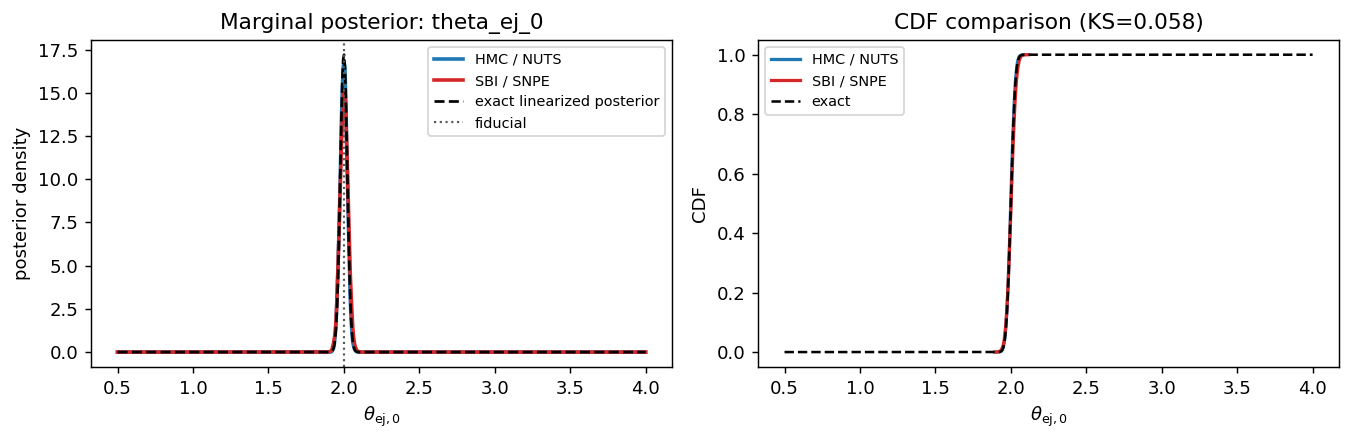

In [7]:
npar = len(names)
fig, axes = plt.subplots(npar, 2, figsize=(10.5, 3.5 * npar), squeeze=False)
for i, (name, label) in enumerate(zip(names, labels)):
    grid = np.linspace(prior_min[i], prior_max[i], 600)
    h = hmc_samples[:, i]
    s = sbi_samples[:, i]

    ax = axes[i, 0]
    ax.plot(grid, stats.gaussian_kde(h)(grid), color="#1f77b4", lw=2.0, label="HMC / NUTS")
    ax.plot(grid, stats.gaussian_kde(s)(grid), color="#d62728", lw=2.0, label="SBI / SNPE")
    if exact_posterior is not None:
        ax.plot(grid, exact_posterior.pdf(grid), color="black", ls="--", lw=1.5, label="exact linearized posterior")
    ax.axvline(fiducial[i], color="0.35", ls=":", lw=1.2, label="fiducial")
    ax.set_xlabel(f"${label}$")
    ax.set_ylabel("posterior density")
    ax.set_title(f"Marginal posterior: {name}")
    ax.legend(fontsize=8)

    ax = axes[i, 1]
    hsort = np.sort(h)
    ssort = np.sort(s)
    ax.plot(hsort, np.arange(1, len(hsort) + 1) / len(hsort), color="#1f77b4", lw=1.8, label="HMC / NUTS")
    ax.plot(ssort, np.arange(1, len(ssort) + 1) / len(ssort), color="#d62728", lw=1.8, label="SBI / SNPE")
    if exact_posterior is not None:
        ax.plot(grid, exact_posterior.cdf(grid), color="black", ls="--", lw=1.4, label="exact")
    ax.set_xlabel(f"${label}$")
    ax.set_ylabel("CDF")
    ax.set_title(f"CDF comparison (KS={rows[i]['KS distance']:.3f})")
    ax.legend(fontsize=8)
fig.tight_layout()

if npar == 2:
    from getdist import MCSamples, plots

    settings = {"smooth_scale_1D": 0.35, "smooth_scale_2D": 0.35}
    hmc_gd = MCSamples(samples=hmc_samples, names=names, labels=labels, label="HMC / NUTS", settings=settings)
    sbi_gd = MCSamples(samples=sbi_samples, names=names, labels=labels, label="SBI / SNPE", settings=settings)
    g = plots.get_subplot_plotter(width_inch=6.2)
    g.settings.legend_fontsize = 9
    g.triangle_plot(
        [hmc_gd, sbi_gd],
        params=names,
        filled=True,
        contour_colors=["#1f77b4", "#d62728"],
        legend_labels=["HMC / NUTS", "SBI / SNPE"],
        markers={name: value for name, value in zip(names, fiducial)},
        marker_args={"color": "black", "lw": 1.1, "ls": "--"},
    )

## Sampler diagnostics

Agreement is only meaningful if the reference chain has mixed.  The
next cell reports R-hat, effective sample size, acceptance, and
divergences, and shows each post-warmup chain separately.

,diagnostic,value
0,max R-hat,1.000000
1,min bulk ESS,4523.000000
2,divergences,0.000000
3,mean acceptance probability,0.951961


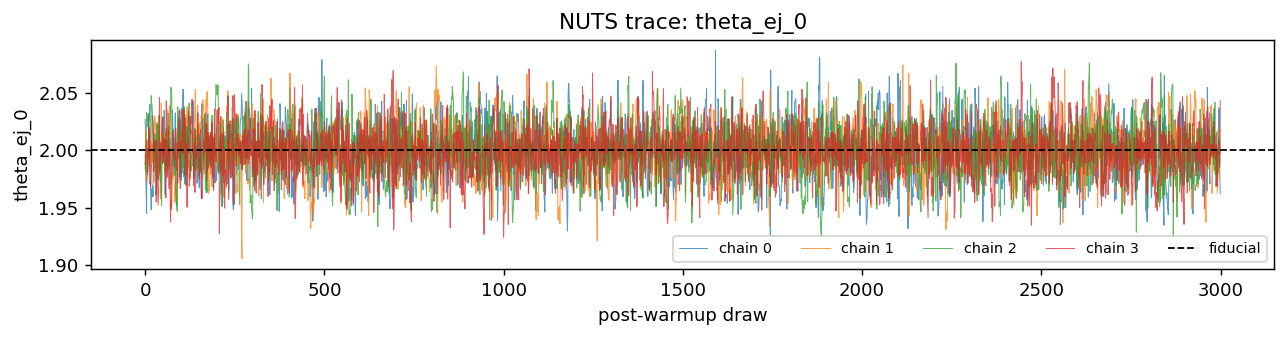

In [8]:
chain_samples = {
    name: np.asarray(hmc[f"samples_chain_{name}"])
    for name in names
}
fig, axes = plt.subplots(npar, 1, figsize=(10, 2.7 * npar), squeeze=False)
for i, name in enumerate(names):
    ax = axes[i, 0]
    for ichain, chain in enumerate(chain_samples[name]):
        ax.plot(chain, lw=0.55, alpha=0.75, label=f"chain {ichain}")
    ax.axhline(fiducial[i], color="black", ls="--", lw=1.0, label="fiducial")
    ax.set_xlabel("post-warmup draw")
    ax.set_ylabel(name)
    ax.set_title(f"NUTS trace: {name}")
axes[0, 0].legend(ncol=5, fontsize=8)
fig.tight_layout()

divergences = int(np.asarray(hmc["extra_diverging"]).sum())
mean_acceptance = float(np.asarray(hmc["extra_accept_prob"]).mean())
diagnostic_summary = pd.DataFrame(
    [
        {"diagnostic": "max R-hat", "value": hmc_diag.get("max_rhat")},
        {"diagnostic": "min bulk ESS", "value": hmc_diag.get("min_ess_bulk")},
        {"diagnostic": "divergences", "value": divergences},
        {"diagnostic": "mean acceptance probability", "value": mean_acceptance},
    ]
)
display(diagnostic_summary)

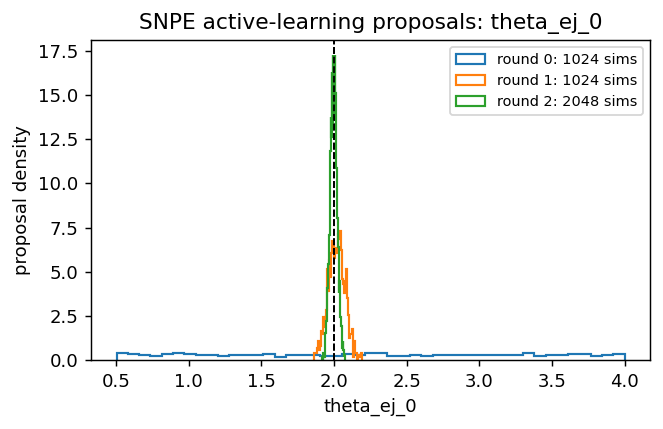

In [9]:
round_paths = sorted(SBI_RUN_DIR.glob("sbi_round*_simulations.npz"))
if round_paths:
    fig, axes = plt.subplots(1, npar, figsize=(5.2 * npar, 3.4), squeeze=False)
    for iround, path in enumerate(round_paths):
        theta_round = np.load(path)["theta"].reshape(-1, npar)
        for i, name in enumerate(names):
            axes[0, i].hist(
                theta_round[:, i],
                bins=45,
                density=True,
                histtype="step",
                lw=1.2,
                label=f"round {iround}: {len(theta_round)} sims",
            )
            axes[0, i].axvline(fiducial[i], color="black", ls="--", lw=1.0)
            axes[0, i].set_xlabel(name)
            axes[0, i].set_ylabel("proposal density")
            axes[0, i].set_title(f"SNPE active-learning proposals: {name}")
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout()

In [10]:
hmc_converged = (
    divergences == 0
    and (hmc_diag.get("max_rhat") is None or hmc_diag["max_rhat"] <= 1.01)
)
posterior_agrees = all(agreement_flags)

print("HMC convergence check:", "PASS" if hmc_converged else "CHECK DIAGNOSTICS")
print("HMC--SBI posterior agreement:", "PASS" if posterior_agrees else "CHECK COMPARISON")
if exact_posterior is not None:
    print(
        "Exact 1D posterior mean/std:",
        f"{float(exact_posterior.mean()):.6f}",
        f"{float(exact_posterior.std()):.6f}",
    )
print()
print('To use gtau, set DATAVECTOR = "gtau" and rerun all cells.')
print('To compare the original two-parameter space, set PARAMETER_MODE = "2d" and rerun all cells.')

HMC convergence check: PASS
HMC--SBI posterior agreement: CHECK COMPARISON
Exact 1D posterior mean/std: 2.000000 0.023120

To use gtau, set DATAVECTOR = "gtau" and rerun all cells.
To compare the original two-parameter space, set PARAMETER_MODE = "2d" and rerun all cells.
